In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


if 'google.colab' in str(get_ipython()):
    print("Berjalan di Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECTS/fb-intelligence")
else:
    print("Berjalan di Komputer Lokal")
    current_dir = Path.cwd()
    PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir

# Registrasikan Root Project ke Python Path & Ubah Working Directory
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

# Path Data
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root  :", PROJECT_ROOT)

Berjalan di Komputer Lokal
Project root  : d:\Project\Python\Machine-Learning\fb-intelligence


In [2]:
from src.features.forecasting import (
    create_forecasting_dataset,
)

In [3]:
demand = pd.read_csv(
    DATA_DIR / "daily_demand.csv",
    parse_dates=["date"],
)

forecasting_df = create_forecasting_dataset(
    demand
)

forecasting_df = forecasting_df.sort_values(
    [
        "date",
        "branch_id",
        "product_id",
    ]
).reset_index(drop=True)

print(
    "Forecasting dataset:",
    forecasting_df.shape,
)

Forecasting dataset: (351500, 23)


In [4]:
train = forecasting_df[
    forecasting_df["date"] <= "2025-06-30"
].copy()

validation = forecasting_df[
    (
        forecasting_df["date"] >= "2025-07-01"
    )
    &
    (
        forecasting_df["date"] <= "2025-09-30"
    )
].copy()

test = forecasting_df[
    forecasting_df["date"] >= "2025-10-01"
].copy()


print("TRAIN")
print(
    train["date"].min(),
    "→",
    train["date"].max(),
    train.shape,
)

print("\nVALIDATION")
print(
    validation["date"].min(),
    "→",
    validation["date"].max(),
    validation.shape,
)

print("\nTEST")
print(
    test["date"].min(),
    "→",
    test["date"].max(),
    test.shape,
)

TRAIN
2024-01-29 00:00:00 → 2025-06-30 00:00:00 (259500, 23)

VALIDATION
2025-07-01 00:00:00 → 2025-09-30 00:00:00 (46000, 23)

TEST
2025-10-01 00:00:00 → 2025-12-31 00:00:00 (46000, 23)


In [5]:
def evaluate_forecast(
    y_true,
    y_pred,
):
    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    r2 = r2_score(
        y_true,
        y_pred,
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

In [6]:
validation_naive1 = validation[
    [
        "date",
        "branch_id",
        "product_id",
        "quantity",
        "lag_1",
    ]
].copy()

metrics_naive1 = evaluate_forecast(
    validation_naive1["quantity"],
    validation_naive1["lag_1"],
)

metrics_naive1

{'MAE': 19.71236956521739,
 'RMSE': np.float64(27.155630771696238),
 'R2': 0.4617536559275348}

In [7]:
validation_naive7 = validation[
    [
        "date",
        "branch_id",
        "product_id",
        "quantity",
        "lag_7",
    ]
].copy()

metrics_naive7 = evaluate_forecast(
    validation_naive7["quantity"],
    validation_naive7["lag_7"],
)

metrics_naive7

{'MAE': 18.970695652173912,
 'RMSE': np.float64(26.10375285363157),
 'R2': 0.5026441890354918}

In [8]:
baseline_results = pd.DataFrame(
    [
        {
            "Model": "Naive-1",
            **metrics_naive1,
        },
        {
            "Model": "Seasonal Naive-7",
            **metrics_naive7,
        },
    ]
)

baseline_results

,Model,MAE,RMSE,R2
0,Naive-1,19.712370,27.155631,0.461754
1,Seasonal Naive-7,18.970696,26.103753,0.502644


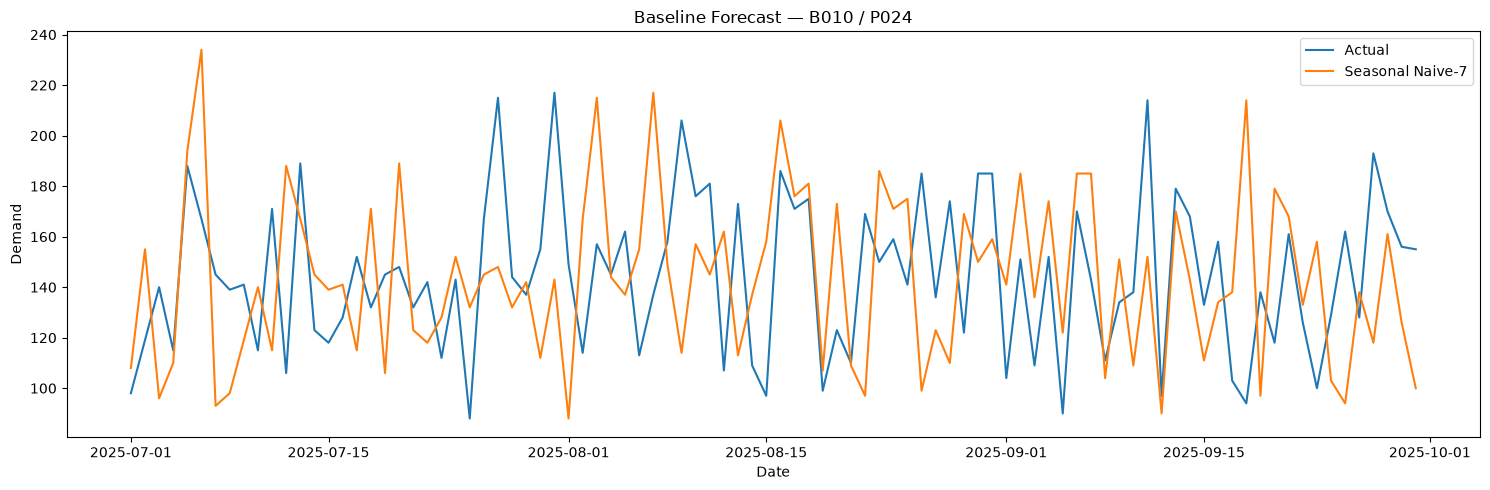

In [9]:
plot_data = validation[
    validation["branch_id"].eq("B010")
    &
    validation["product_id"].eq("P024")
].copy()

plot_data = plot_data.sort_values(
    "date"
)

plt.figure(figsize=(15, 5))

plt.plot(
    plot_data["date"],
    plot_data["quantity"],
    label="Actual",
)

plt.plot(
    plot_data["date"],
    plot_data["lag_7"],
    label="Seasonal Naive-7",
)

plt.title(
    "Baseline Forecast — B010 / P024"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
def mean_absolute_percentage_error(
    y_true,
    y_pred,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return (
        np.mean(
            np.abs(
                (y_true - y_pred)
                / y_true
            )
        )
        * 100
    )

In [11]:
def evaluate_forecast(
    y_true,
    y_pred,
):
    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    r2 = r2_score(
        y_true,
        y_pred,
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred,
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
    }

Feature Configuration

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor


TARGET = "quantity"


FEATURES = [
    "branch_id",
    "product_id",

    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_payday",
    "is_holiday",

    "discount_percentage",

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",

    "rolling_mean_7",
    "rolling_std_7",

    "rolling_mean_14",
    "rolling_std_14",

    "rolling_mean_28",
    "rolling_std_28",
]


CATEGORICAL_FEATURES = [
    "branch_id",
    "product_id",
]


NUMERIC_FEATURES = [
    feature
    for feature in FEATURES
    if feature not in CATEGORICAL_FEATURES
]


print("Total features:", len(FEATURES))
print("Categorical:", CATEGORICAL_FEATURES)
print("Numeric:", len(NUMERIC_FEATURES))

Total features: 21
Categorical: ['branch_id', 'product_id']
Numeric: 19


In [13]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_validation = validation[FEATURES]
y_validation = validation[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (259500, 21)
y_train: (259500,)
X_validation: (46000, 21)
y_validation: (46000,)
X_test: (46000, 21)
y_test: (46000,)


Preprocessing

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="passthrough",
)

## Random Forest

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

In [16]:
X_train_encoded = preprocessor.fit_transform(
    X_train
)

X_validation_encoded = preprocessor.transform(
    X_validation
)

X_test_encoded = preprocessor.transform(
    X_test
)


print(
    "Encoded train:",
    X_train_encoded.shape,
)

print(
    "Encoded validation:",
    X_validation_encoded.shape,
)

print(
    "Encoded test:",
    X_test_encoded.shape,
)

Encoded train: (259500, 21)
Encoded validation: (46000, 21)
Encoded test: (46000, 21)


In [17]:
rf_model.fit(
    X_train_encoded,
    y_train,
)

print(
    "Random Forest training completed."
)

Random Forest training completed.


Validation Prediction

In [18]:
rf_validation_pred = (
    rf_model.predict(
        X_validation_encoded
    )
)

rf_validation_pred = np.maximum(
    rf_validation_pred,
    0,
)

In [19]:
rf_metrics = evaluate_forecast(
    y_validation,
    rf_validation_pred,
)

rf_metrics

{'MAE': 13.298746934401658,
 'RMSE': np.float64(18.224913308614862),
 'MAPE': np.float64(21.77756158625202),
 'R2': 0.7575667180080343}

In [20]:
comparison = pd.DataFrame(
    [
        {
            "Model": "Seasonal Naive-7",
            **metrics_naive7,
        },
        {
            "Model": "Random Forest",
            **rf_metrics,
        },
    ]
)

comparison

,Model,MAE,RMSE,R2,MAPE
0,Seasonal Naive-7,18.970696,26.103753,0.502644,NaN
1,Random Forest,13.298747,18.224913,0.757567,21.777562


Feature Importance

In [21]:
feature_importance = pd.DataFrame(
    {
        "feature": FEATURES,
        "importance": rf_model.feature_importances_,
    }
).sort_values(
    "importance",
    ascending=False,
)

feature_importance

,feature,importance
19,rolling_mean_28,0.788689
2,day_of_week,0.027871
6,is_weekend,0.022515
3,day_of_month,0.015372
20,rolling_std_28,0.012408
16,rolling_std_7,0.012273
18,rolling_std_14,0.011489
17,rolling_mean_14,0.011443
14,lag_28,0.011360
15,rolling_mean_7,0.011296


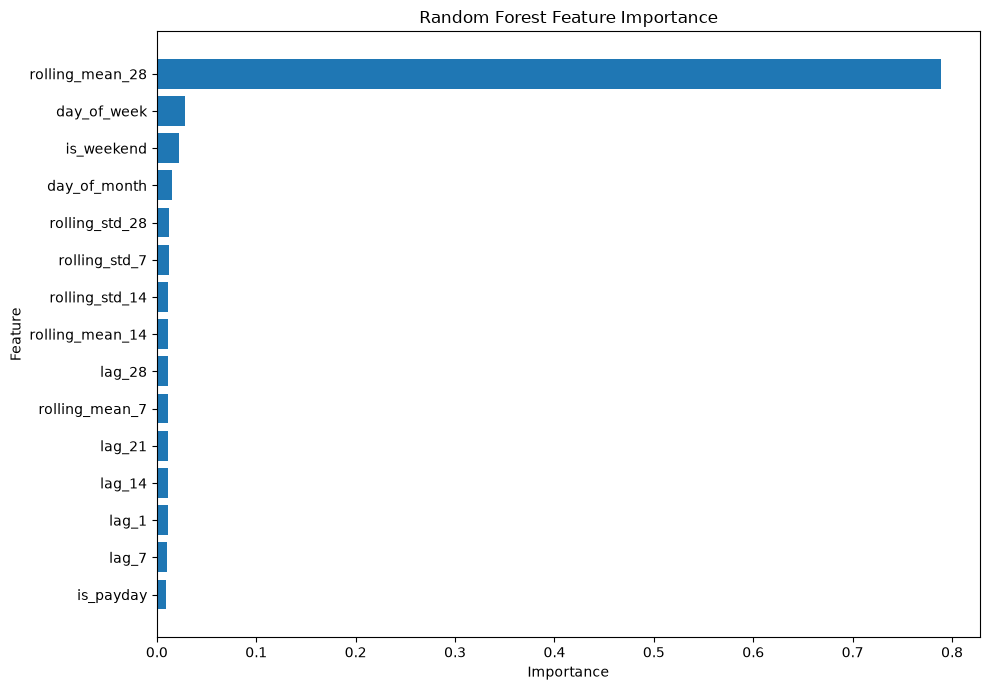

In [22]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Cek performance per-branch

In [23]:
validation_results = validation[
    [
        "date",
        "branch_id",
        "product_id",
        "quantity",
    ]
].copy()

validation_results["prediction"] = (
    rf_validation_pred
)

branch_performance = (
    validation_results
    .groupby("branch_id")
    .apply(
        lambda x: pd.Series(
            evaluate_forecast(
                x["quantity"],
                x["prediction"],
            )
        ),
        include_groups=False,
    )
    .reset_index()
)

branch_performance

,branch_id,MAE,RMSE,MAPE,R2
0,B001,11.181910,14.852511,22.793566,0.711897
1,B002,14.400692,19.234874,20.922539,0.728184
2,B003,10.880902,14.631969,22.448567,0.713476
3,B004,14.305797,19.588591,21.659845,0.705244
4,B005,15.434591,20.911461,21.067738,0.710934
5,B006,14.488426,19.748883,21.269433,0.713387
6,B007,10.173898,13.839451,22.822748,0.688485
7,B008,10.207353,13.803148,23.706663,0.687288
8,B009,15.393864,20.673814,20.369779,0.743805
9,B010,16.520037,22.278202,20.714737,0.730747


In [24]:
product_performance = (
    validation_results
    .groupby("product_id")
    .apply(
        lambda x: pd.Series(
            evaluate_forecast(
                x["quantity"],
                x["prediction"],
            )
        ),
        include_groups=False,
    )
    .reset_index()
)

product_performance.sort_values(
    "MAE",
    ascending=True,
).head(10)

,product_id,MAE,RMSE,MAPE,R2
19,P020,5.253957,6.744370,27.937165,0.381032
38,P039,5.433322,6.973722,26.074797,0.402325
46,P047,5.731577,7.314316,26.944769,0.343030
25,P026,5.797788,7.434506,26.622382,0.361766
14,P015,6.650870,8.611180,24.155131,0.425211
16,P017,6.857567,8.585325,25.536866,0.422155
0,P001,7.342435,9.370747,24.339094,0.409631
28,P029,7.675028,9.880478,23.947023,0.423670
6,P007,7.980689,10.105594,24.631445,0.372302
11,P012,8.044209,10.262185,23.782345,0.404373


In [25]:
product_performance.sort_values(
    "MAE",
    ascending=False,
).head(10)

,product_id,MAE,RMSE,MAPE,R2
23,P024,20.444691,26.857341,18.262135,0.492647
13,P014,20.329518,26.514767,20.407443,0.454826
29,P030,20.262535,26.631896,19.953406,0.488106
40,P041,19.775710,24.965530,20.227764,0.486016
8,P009,19.622943,25.451811,19.889359,0.448817
4,P005,18.917014,24.314449,18.916815,0.491922
41,P042,18.561450,24.164205,20.423011,0.476289
3,P004,18.258752,24.112066,19.382051,0.453254
26,P027,18.215398,23.824820,18.815058,0.514617
5,P006,18.122264,23.557093,21.847644,0.440537


Helper Function

In [26]:
def train_and_evaluate_rf(
    feature_list,
):
    categorical = [
        feature
        for feature in feature_list
        if feature in [
            "branch_id",
            "product_id",
        ]
    ]

    preprocessor_exp = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
                categorical,
            ),
        ],
        remainder="passthrough",
    )

    X_tr = train[feature_list]
    X_val = validation[feature_list]

    X_tr_encoded = (
        preprocessor_exp.fit_transform(X_tr)
    )

    X_val_encoded = (
        preprocessor_exp.transform(X_val)
    )

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_tr_encoded,
        y_train,
    )

    prediction = model.predict(
        X_val_encoded
    )

    prediction = np.maximum(
        prediction,
        0,
    )

    metrics = evaluate_forecast(
        y_validation,
        prediction,
    )

    return metrics

Full Model

In [27]:
rf_full_features = FEATURES.copy()

rf_full_metrics = (
    train_and_evaluate_rf(
        rf_full_features
    )
)

rf_full_metrics

{'MAE': 13.298746934401658,
 'RMSE': np.float64(18.224913308614862),
 'MAPE': np.float64(21.77756158625202),
 'R2': 0.7575667180080343}

Remove rolling_mean_28

In [28]:
rf_without_28 = [
    feature
    for feature in FEATURES
    if feature != "rolling_mean_28"
]

rf_without_28_metrics = (
    train_and_evaluate_rf(
        rf_without_28
    )
)

rf_without_28_metrics

{'MAE': 13.412261216701651,
 'RMSE': np.float64(18.40941603208572),
 'MAPE': np.float64(21.916055903200228),
 'R2': 0.752633249899218}

Historical features only

In [29]:
historical_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",

    "rolling_mean_7",
    "rolling_std_7",

    "rolling_mean_14",
    "rolling_std_14",

    "rolling_std_28",
]

rf_historical_metrics = (
    train_and_evaluate_rf(
        historical_features
    )
)

rf_historical_metrics

{'MAE': 14.334803292646766,
 'RMSE': np.float64(19.69858319912004),
 'MAPE': np.float64(23.60773738211294),
 'R2': 0.7167751987357326}

Comparison

In [30]:
ablation_results = pd.DataFrame(
    [
        {
            "Experiment": "Full RF",
            **rf_full_metrics,
        },
        {
            "Experiment": "Without rolling_mean_28",
            **rf_without_28_metrics,
        },
        {
            "Experiment": "Historical features only",
            **rf_historical_metrics,
        },
    ]
)

ablation_results

,Experiment,MAE,RMSE,MAPE,R2
0,Full RF,13.298747,18.224913,21.777562,0.757567
1,Without rolling_mean_28,13.412261,18.409416,21.916056,0.752633
2,Historical features only,14.334803,19.698583,23.607737,0.716775


## XGBoost

In [31]:
from xgboost import XGBRegressor

Preprocessing XGBoost

In [32]:
categorical_features = [
    "branch_id",
    "product_id",
]

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            categorical_features,
        ),
    ],
    remainder="passthrough",
)

X_train_xgb = train[FEATURES]
X_validation_xgb = validation[FEATURES]

X_train_xgb_encoded = preprocessor_xgb.fit_transform(X_train_xgb)
X_validation_xgb_encoded = preprocessor_xgb.transform(X_validation_xgb)

print("Train shape:", X_train_xgb_encoded.shape)
print("Validation shape:", X_validation_xgb_encoded.shape)

Train shape: (259500, 21)
Validation shape: (46000, 21)


XGBoost Baseline

In [33]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_xgb_encoded,
    y_train,
)

xgb_prediction = xgb_model.predict(
    X_validation_xgb_encoded
)

xgb_prediction = np.maximum(xgb_prediction, 0)

xgb_metrics = evaluate_forecast(
    y_validation,
    xgb_prediction,
)

xgb_metrics

{'MAE': 13.179326057434082,
 'RMSE': np.float64(18.188526032860576),
 'MAPE': np.float64(21.426615319128338),
 'R2': 0.7585338354110718}

Bandingkan RF vs XGBoost

In [39]:
model_comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive-7",
        **metrics_naive7
    },
    {
        "Model": "Random Forest",
        **rf_metrics,
    },
    {
        "Model": "XGBoost",
        **xgb_metrics,
    },
])

model_comparison

,Model,MAE,RMSE,R2,MAPE
0,Seasonal Naive-7,18.970696,26.103753,0.502644,NaN
1,Random Forest,13.298747,18.224913,0.757567,21.777562
2,XGBoost,13.179326,18.188526,0.758534,21.426615


In [40]:
xgb_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_model.feature_importances_,
}).sort_values(
    "importance",
    ascending=False,
)

xgb_importance

,feature,importance
19,rolling_mean_28,0.405213
6,is_weekend,0.289037
15,rolling_mean_7,0.122981
2,day_of_week,0.048246
7,is_payday,0.035431
17,rolling_mean_14,0.032475
3,day_of_month,0.012670
20,rolling_std_28,0.007578
8,is_holiday,0.005926
14,lag_28,0.004753


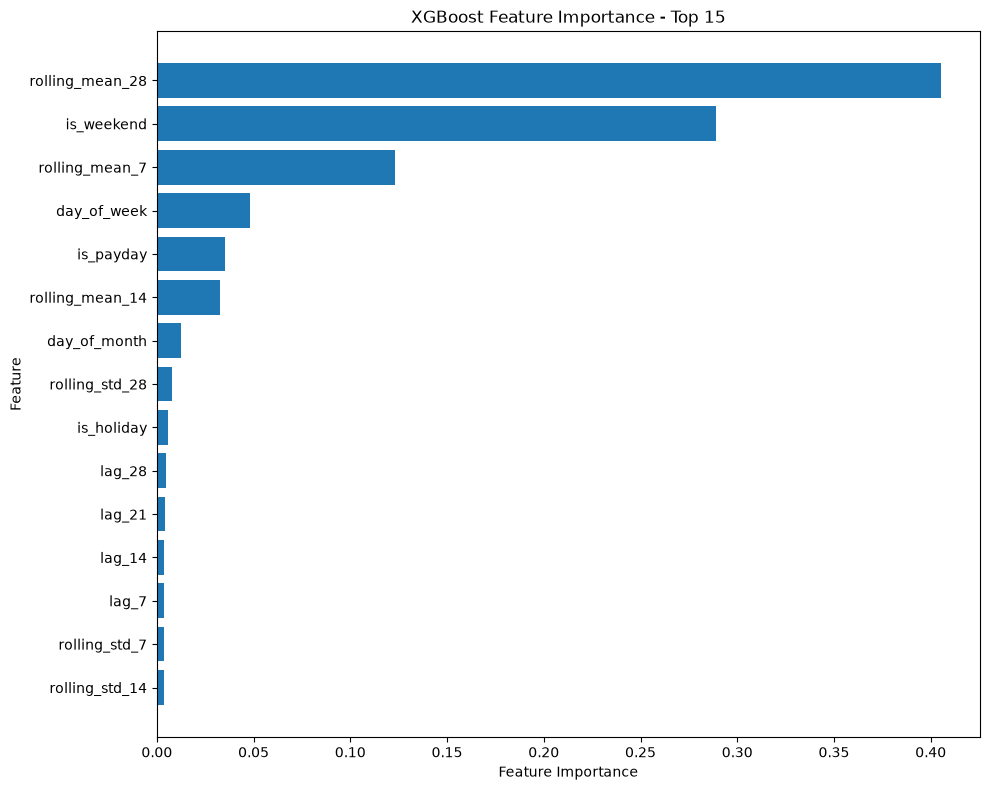

In [41]:
plt.figure(figsize=(10, 8))

plt.barh(
    xgb_importance["feature"].head(15)[::-1],
    xgb_importance["importance"].head(15)[::-1],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance - Top 15")

plt.tight_layout()
plt.show()

Helper

In [42]:
def train_and_evaluate_xgb(feature_list):
    categorical_features = [
        feature
        for feature in feature_list
        if feature in ["branch_id", "product_id"]
    ]

    preprocessor_exp = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
                categorical_features,
            ),
        ],
        remainder="passthrough",
    )

    X_tr = train[feature_list]
    X_val = validation[feature_list]

    X_tr_encoded = preprocessor_exp.fit_transform(X_tr)
    X_val_encoded = preprocessor_exp.transform(X_val)

    model = XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_tr_encoded,
        y_train,
    )

    prediction = model.predict(X_val_encoded)
    prediction = np.maximum(prediction, 0)

    metrics = evaluate_forecast(
        y_validation,
        prediction,
    )

    return metrics

In [43]:
xgb_full_metrics = train_and_evaluate_xgb(FEATURES)

In [44]:
xgb_without_28 = [
    feature
    for feature in FEATURES
    if feature != "rolling_mean_28"
]

xgb_without_28_metrics = train_and_evaluate_xgb(
    xgb_without_28
)

In [45]:
xgb_without_weekend = [
    feature
    for feature in FEATURES
    if feature != "is_weekend"
]

xgb_without_weekend_metrics = train_and_evaluate_xgb(
    xgb_without_weekend
)

In [46]:
xgb_without_28_weekend = [
    feature
    for feature in FEATURES
    if feature not in [
        "rolling_mean_28",
        "is_weekend",
    ]
]

xgb_without_28_weekend_metrics = train_and_evaluate_xgb(
    xgb_without_28_weekend
)

In [47]:
xgb_ablation_results = pd.DataFrame([
    {
        "Experiment": "Full XGBoost",
        **xgb_full_metrics,
    },
    {
        "Experiment": "Without rolling_mean_28",
        **xgb_without_28_metrics,
    },
    {
        "Experiment": "Without is_weekend",
        **xgb_without_weekend_metrics,
    },
    {
        "Experiment": "Without rolling_mean_28 + is_weekend",
        **xgb_without_28_weekend_metrics,
    },
])

xgb_ablation_results

,Experiment,MAE,RMSE,MAPE,R2
0,Full XGBoost,13.179326,18.188526,21.426615,0.758534
1,Without rolling_mean_28,13.273026,18.401418,21.443718,0.752848
2,Without is_weekend,13.184587,18.192364,21.436476,0.758432
3,Without rolling_mean_28 + is_weekend,13.279119,18.413163,21.440072,0.752533


#### XGBoost Hyperparameter Tuning

In [48]:
xgb_exp_1 = XGBRegressor(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_exp_1.fit(
    X_train_xgb_encoded,
    y_train,
)

pred_exp_1 = np.maximum(
    xgb_exp_1.predict(X_validation_xgb_encoded),
    0
)

metrics_exp_1 = evaluate_forecast(
    y_validation,
    pred_exp_1,
)

metrics_exp_1

{'MAE': 13.228690147399902,
 'RMSE': np.float64(18.309821756475575),
 'MAPE': np.float64(21.387360529180206),
 'R2': 0.7553024888038635}

In [49]:
xgb_exp_2 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_exp_2.fit(
    X_train_xgb_encoded,
    y_train,
)

pred_exp_2 = np.maximum(
    xgb_exp_2.predict(X_validation_xgb_encoded),
    0
)

metrics_exp_2 = evaluate_forecast(
    y_validation,
    pred_exp_2,
)

metrics_exp_2

{'MAE': 13.153862953186035,
 'RMSE': np.float64(18.104938217011316),
 'MAPE': np.float64(21.472721566274657),
 'R2': 0.7607480883598328}

In [50]:
xgb_exp_3 = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_exp_3.fit(
    X_train_xgb_encoded,
    y_train,
)

pred_exp_3 = np.maximum(
    xgb_exp_3.predict(X_validation_xgb_encoded),
    0
)

metrics_exp_3 = evaluate_forecast(
    y_validation,
    pred_exp_3,
)

In [51]:
tuning_results = pd.DataFrame([
    {
        "Experiment": "XGBoost Baseline",
        **xgb_metrics,
    },
    {
        "Experiment": "600 trees, depth 8",
        **metrics_exp_1,
    },
    {
        "Experiment": "300 trees, depth 6",
        **metrics_exp_2,
    },
    {
        "Experiment": "600 trees, depth 6, LR 0.03",
        **metrics_exp_3,
    },
])

tuning_results

,Experiment,MAE,RMSE,MAPE,R2
0,XGBoost Baseline,13.179326,18.188526,21.426615,0.758534
1,"600 trees, depth 8",13.228690,18.309822,21.387361,0.755302
2,"300 trees, depth 6",13.153863,18.104938,21.472722,0.760748
3,"600 trees, depth 6, LR 0.03",13.149655,18.101890,21.455234,0.760829


## TEST SET

In [52]:
train_validation = pd.concat(
    [train, validation],
    ignore_index=True,
)

X_train_val = train_validation[FEATURES]
y_train_val = train_validation["quantity"]

X_test = test[FEATURES]
y_test = test["quantity"]

print("Train + Validation:", train_validation.shape)
print("Test:", test.shape)

Train + Validation: (305500, 23)
Test: (46000, 23)


In [53]:
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            ["branch_id", "product_id"],
        ),
    ],
    remainder="passthrough",
)

X_train_val_encoded = preprocessor_final.fit_transform(
    X_train_val
)

X_test_encoded = preprocessor_final.transform(
    X_test
)

In [54]:
final_xgb_model = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

final_xgb_model.fit(
    X_train_val_encoded,
    y_train_val,
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [55]:
test_prediction = final_xgb_model.predict(
    X_test_encoded
)

test_prediction = np.maximum(
    test_prediction,
    0
)

test_metrics = evaluate_forecast(
    y_test,
    test_prediction,
)

test_metrics

{'MAE': 13.521475791931152,
 'RMSE': np.float64(18.69056824466805),
 'MAPE': np.float64(21.21596288097694),
 'R2': 0.7596907019615173}

In [56]:
final_results = pd.DataFrame([
    {
        "Dataset": "Validation",
        "Model": "XGBoost tuned",
        "MAE": metrics_exp_3["MAE"],
        "RMSE": metrics_exp_3["RMSE"],
        "MAPE": metrics_exp_3["MAPE"],
        "R2": metrics_exp_3["R2"],
    },
    {
        "Dataset": "Test",
        "Model": "XGBoost tuned",
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "MAPE": test_metrics["MAPE"],
        "R2": test_metrics["R2"],
    },
])

final_results

,Dataset,Model,MAE,RMSE,MAPE,R2
0,Validation,XGBoost tuned,13.149655,18.101890,21.455234,0.760829
1,Test,XGBoost tuned,13.521476,18.690568,21.215963,0.759691


## TEST: Baseline vs XGBoost Final

In [57]:
test_naive_prediction = test["lag_7"].values

test_naive_prediction = np.maximum(
    test_naive_prediction,
    0
)

test_naive_metrics = evaluate_forecast(
    y_test,
    test_naive_prediction,
)

test_naive_metrics

{'MAE': 19.474652173913043,
 'RMSE': np.float64(26.85289798950539),
 'MAPE': np.float64(30.050633036786028),
 'R2': 0.503970082673489}

In [58]:
test_comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive-7",
        **test_naive_metrics,
    },
    {
        "Model": "XGBoost tuned",
        **test_metrics,
    },
])

test_comparison

,Model,MAE,RMSE,MAPE,R2
0,Seasonal Naive-7,19.474652,26.852898,30.050633,0.503970
1,XGBoost tuned,13.521476,18.690568,21.215963,0.759691


## **LSTM**

In [59]:
LSTM_FEATURES = [
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "is_payday",
    "is_holiday",
    "discount_percentage",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "rolling_std_14",
    "rolling_mean_28",
    "rolling_std_28",
]

In [60]:
TARGET = "quantity"

In [61]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_lstm_scaled = feature_scaler.fit_transform(
    train[LSTM_FEATURES]
)

X_validation_lstm_scaled = feature_scaler.transform(
    validation[LSTM_FEATURES]
)

X_test_lstm_scaled = feature_scaler.transform(
    test[LSTM_FEATURES]
)

y_train_lstm_scaled = target_scaler.fit_transform(
    train[[TARGET]]
)

y_validation_lstm_scaled = target_scaler.transform(
    validation[[TARGET]]
)

y_test_lstm_scaled = target_scaler.transform(
    test[[TARGET]]
)

print("Train X:", X_train_lstm_scaled.shape)
print("Validation X:", X_validation_lstm_scaled.shape)
print("Test X:", X_test_lstm_scaled.shape)

Train X: (259500, 19)
Validation X: (46000, 19)
Test X: (46000, 19)


In [62]:
def create_lstm_sequences(
    df,
    feature_columns,
    target_column,
    lookback,
    feature_scaler,
    target_scaler,
):
    X_sequences = []
    y_sequences = []

    for (_, _), group in df.groupby(
        ["branch_id", "product_id"],
        sort=False
    ):
        group = group.sort_values("date").reset_index(drop=True)

        X = feature_scaler.transform(
            group[feature_columns]
        )

        y = target_scaler.transform(
            group[[target_column]]
        )

        for i in range(lookback, len(group)):
            X_sequences.append(
                X[i - lookback:i]
            )

            y_sequences.append(
                y[i]
            )

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
    )

In [63]:
LOOKBACK = 7

lstm_full = pd.concat(
    [train, validation, test],
    ignore_index=True,
)

lstm_full = lstm_full.sort_values(
    ["branch_id", "product_id", "date"]
).reset_index(drop=True)

print(lstm_full.shape)
print(
    lstm_full[
        ["date", "branch_id", "product_id", "quantity"]
    ].head(10)
)

(351500, 23)
        date branch_id product_id  quantity
0 2024-01-29      B001       P001        24
1 2024-01-30      B001       P001        32
2 2024-01-31      B001       P001        15
3 2024-02-01      B001       P001        19
4 2024-02-02      B001       P001        25
5 2024-02-03      B001       P001        16
6 2024-02-04      B001       P001        22
7 2024-02-05      B001       P001        19
8 2024-02-06      B001       P001        14
9 2024-02-07      B001       P001        15


In [64]:
def create_lstm_sequences_with_metadata(
    df,
    feature_columns,
    target_column,
    lookback,
    feature_scaler,
    target_scaler,
):
    X_sequences = []
    y_sequences = []
    metadata = []

    for (branch_id, product_id), group in df.groupby(
        ["branch_id", "product_id"],
        sort=False
    ):
        group = group.sort_values("date").reset_index(drop=True)

        X = feature_scaler.transform(
            group[feature_columns]
        )

        y = target_scaler.transform(
            group[[target_column]]
        )

        for i in range(lookback, len(group)):
            X_sequences.append(
                X[i - lookback:i]
            )

            y_sequences.append(
                y[i]
            )

            metadata.append({
                "date": group.loc[i, "date"],
                "branch_id": branch_id,
                "product_id": product_id,
            })

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
        pd.DataFrame(metadata),
    )

In [65]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(
    train[LSTM_FEATURES]
)

target_scaler.fit(
    train[[TARGET]]
)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[308.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[1.]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[307.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['quantity']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,259500


In [66]:
X_all_lstm, y_all_lstm, lstm_metadata = (
    create_lstm_sequences_with_metadata(
        lstm_full,
        LSTM_FEATURES,
        TARGET,
        LOOKBACK,
        feature_scaler,
        target_scaler,
    )
)

print("X:", X_all_lstm.shape)
print("y:", y_all_lstm.shape)
print("metadata:", lstm_metadata.shape)

X: (348000, 7, 19)
y: (348000, 1)
metadata: (348000, 3)


In [67]:
train_mask = (
    lstm_metadata["date"] <= "2025-06-30"
)

validation_mask = (
    (lstm_metadata["date"] >= "2025-07-01") &
    (lstm_metadata["date"] <= "2025-09-30")
)

test_mask = (
    lstm_metadata["date"] >= "2025-10-01"
)

X_train_seq = X_all_lstm[train_mask.values]
y_train_seq = y_all_lstm[train_mask.values]

X_validation_seq = X_all_lstm[validation_mask.values]
y_validation_seq = y_all_lstm[validation_mask.values]

X_test_seq = X_all_lstm[test_mask.values]
y_test_seq = y_all_lstm[test_mask.values]

print("Train:", X_train_seq.shape)
print("Validation:", X_validation_seq.shape)
print("Test:", X_test_seq.shape)

Train: (256000, 7, 19)
Validation: (46000, 7, 19)
Test: (46000, 7, 19)


### Bangun LSTM Baseline

In [69]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [70]:
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [71]:
lstm_model = keras.Sequential([
    layers.Input(
        shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2],
        )
    ),

    layers.LSTM(
        64,
        return_sequences=False,
    ),

    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),

    layers.Dense(1),
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"],
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

In [73]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(
        X_validation_seq,
        y_validation_seq,
    ),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0037 - mae: 0.0445 - val_loss: 0.0037 - val_mae: 0.0435
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0032 - mae: 0.0416 - val_loss: 0.0035 - val_mae: 0.0436
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0032 - mae: 0.0412 - val_loss: 0.0036 - val_mae: 0.0440
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0032 - mae: 0.0410 - val_loss: 0.0036 - val_mae: 0.0431
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0032 - mae: 0.0410 - val_loss: 0.0036 - val_mae: 0.0434
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0031 - mae: 0.0409 - val_loss: 0.0037 - val_mae: 0.0433
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0031 - mae: 0.0408 - val_loss: 0.0035 - val_mae: 0.0430
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0031 - mae: 0.0408 - val_loss: 0.0035 - val_mae: 0.0436
Epoch 9/30
1000/1000 ━━━━━━━━━━━━━━━━━━━

In [74]:
print(
    "Epochs trained:",
    len(history.history["loss"])
)

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

Epochs trained: 12
Best validation loss: 0.0035139471292495728


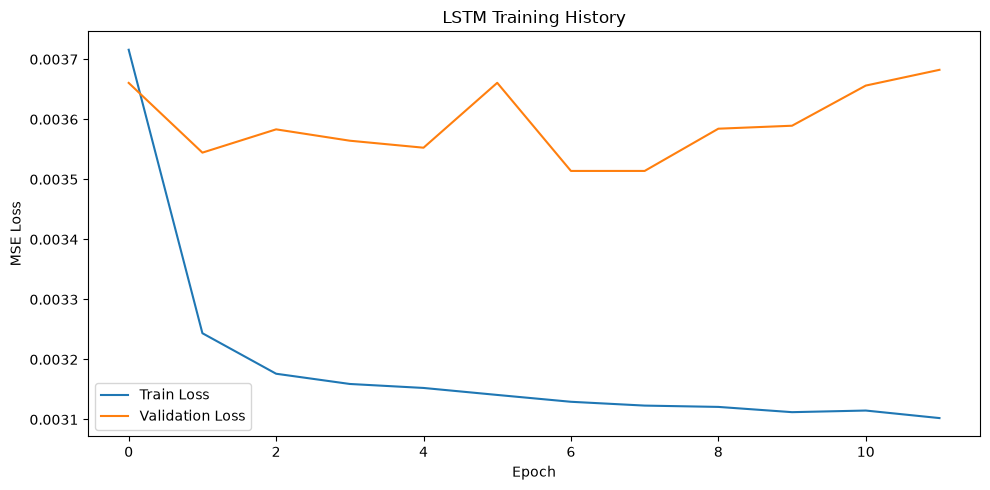

In [75]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss",
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
lstm_validation_scaled = lstm_model.predict(
    X_validation_seq,
    verbose=0,
)

lstm_validation_prediction = target_scaler.inverse_transform(
    lstm_validation_scaled
).ravel()

lstm_validation_actual = target_scaler.inverse_transform(
    y_validation_seq
).ravel()

lstm_validation_prediction = np.maximum(
    lstm_validation_prediction,
    0
)

lstm_validation_metrics = evaluate_forecast(
    lstm_validation_actual,
    lstm_validation_prediction,
)

lstm_validation_metrics

{'MAE': 13.214613914489746,
 'RMSE': np.float64(18.198516550495864),
 'MAPE': np.float32(21.65289),
 'R2': 0.7582684755325317}

In [77]:
validation_comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive-7",
        "MAE": 18.970696,
        "RMSE": 26.103753,
        "MAPE": 30.312473,
        "R2": 0.502644,
    },
    {
        "Model": "Random Forest",
        "MAE": 13.298747,
        "RMSE": 18.224913,
        "MAPE": 21.777562,
        "R2": 0.757567,
    },
    {
        "Model": "XGBoost tuned",
        **metrics_exp_3,
    },
    {
        "Model": "LSTM baseline",
        **lstm_validation_metrics,
    },
])

validation_comparison

,Model,MAE,RMSE,MAPE,R2
0,Seasonal Naive-7,18.970696,26.103753,30.312473,0.502644
1,Random Forest,13.298747,18.224913,21.777562,0.757567
2,XGBoost tuned,13.149655,18.101890,21.455234,0.760829
3,LSTM baseline,13.214614,18.198517,21.652889,0.758268


#### Evaluasi LSTM pada test sebagai model pembanding akhir

In [78]:
lstm_test_scaled = lstm_model.predict(
    X_test_seq,
    verbose=0,
)

lstm_test_prediction = target_scaler.inverse_transform(
    lstm_test_scaled
).ravel()

lstm_test_actual = target_scaler.inverse_transform(
    y_test_seq
).ravel()

lstm_test_prediction = np.maximum(
    lstm_test_prediction,
    0
)

lstm_test_metrics = evaluate_forecast(
    lstm_test_actual,
    lstm_test_prediction,
)

lstm_test_metrics

{'MAE': 13.659747123718262,
 'RMSE': np.float64(18.934514480784735),
 'MAPE': np.float32(21.5004),
 'R2': 0.753376841545105}

In [79]:
test_model_comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive-7",
        **test_naive_metrics,
    },
    {
        "Model": "XGBoost tuned",
        **test_metrics,
    },
    {
        "Model": "LSTM baseline",
        **lstm_test_metrics,
    },
])

test_model_comparison

,Model,MAE,RMSE,MAPE,R2
0,Seasonal Naive-7,19.474652,26.852898,30.050633,0.503970
1,XGBoost tuned,13.521476,18.690568,21.215963,0.759691
2,LSTM baseline,13.659747,18.934514,21.500401,0.753377
